# Analysis of Example 2: magnon cutoff, backends and preconditioner

This notebook starts from the results of `examples/example2_xxz_chain_thermal.ipynb` and asks three questions about the thermal XXZ chain. In this notebook you will:

- load the thermal weights and the $N_{\max}=4$ spectrum saved by the example;
- measure how the rephasing spectrum converges with the magnon cutoff $N_{\max}$;
- check that the dense and sparse backends give the same spectrum;
- count the GMRES iterations with and without the diagonal preconditioner.

The convergence study uses a coarse grid ($15\times15$, a subset of the example's grid) so that each extra cutoff costs seconds. Timing studies as a function of the chain length are benchmarks, in `validation/benchmarks/`.

Natural units: $\hbar=1$, energies in meV, temperature in kelvin.

## 0. Imports

`models.py` in the parent folder builds the XXZ model for any chain length and cutoff, with QuTiP, as in the example. Figures are saved in `results/figure_analysis/`.

In [1]:
import sys
import time

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np

import qudpy_fdgf.backends.sparse_sector as sparse_sector
from qudpy_fdgf import SpectroscopySolver
from models import (ANALYSIS_FIGURES, DATA, EX2, EX2_PATHWAYS, EX2_PROTOCOL, example2_context,
                    example2_model, results_dirs)

results_dirs()
eta = EX2["eta"]
context = example2_context()

## 1. Results of the example

We load the saved calculation: parameters, equilibrium weights $P_N$ of the full six-site chain, and the rephasing spectrum at $N_{\max}=4$.

In [2]:
saved = np.load(DATA / "example2.npz")
reference_N = int(saved["max_magnons"])
omega_1q, omega_emit = saved["omega_1q"], saved["omega_emit"]
reference = saved["rephasing"]
weights = saved["sector_weight"]

print(f"N_max of the example: {reference_N};  grid {reference.shape};  T = {float(saved['temperature'])} K")
print("equilibrium weights P_N:", np.array2string(weights, precision=6))

N_max of the example: 4;  grid (60, 60);  T = 4.0 K
equilibrium weights P_N: [8.853308e-01 1.027335e-01 1.090758e-02 9.547005e-04 6.906641e-05
 4.118975e-06 2.247611e-07]


## 2. How many magnon sectors?

A third-order pathway that starts in sector $N$ can reach $N+2$, so a cutoff $N_{\max}$ gives complete pathways only for initial sectors $N\le N_{\max}-2$. Two numbers measure the loss:

- the *state weight* beyond the cutoff, $\sum_{N>N_{\max}}P_N$;
- the *pathway weight*, $\sum_{N>N_{\max}-2}P_N$, the population of the initial sectors whose third-order paths can leave the retained space.

In [3]:
print(" N_max   state weight   pathway weight")
for N_max in range(2, 6):
    print(f"  {N_max}      {weights[N_max + 1:].sum():.2e}       {weights[N_max - 1:].sum():.2e}")

 N_max   state weight   pathway weight
  2      1.03e-03       1.15e-01
  3      7.34e-05       1.19e-02
  4      4.34e-06       1.03e-03
  5      2.25e-07       7.34e-05


### Convergence of the spectrum

We recompute the rephasing spectrum for $N_{\max}=2,3,5$ on every fourth point of the example's grid, and compare with the saved $N_{\max}=4$ spectrum on the same points. The calculation at $N_{\max}=5$ ($D=63$, nearly the full 64-dimensional space) serves as reference.

N_max = 2:   1.9 s


N_max = 3:   4.2 s


N_max = 5:   8.5 s
N_max = 2: max|S - S(5)| / max|S(5)| = 6.47e-02
N_max = 3: max|S - S(5)| / max|S(5)| = 4.46e-03
N_max = 4: max|S - S(5)| / max|S(5)| = 2.52e-04


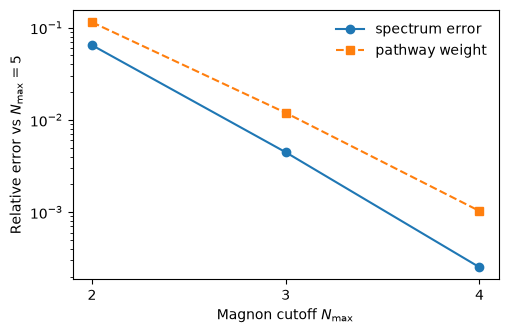

In [4]:
pick = np.arange(0, omega_1q.size, 4)
axes = {"omega_1q": omega_1q[pick], "omega_emit": omega_emit[pick]}


def rephasing_spectrum(model, backend="sparse_sector", context=None, eta=eta, axes=axes, **options):
    solver = SpectroscopySolver(backend=backend, eta=eta, **options)
    solver.feed_model(model, context=context)
    result = solver.generate_spectrum(EX2_PROTOCOL, axes=axes, fixed_coordinates={"t2": 0.0},
                                      pathways=EX2_PATHWAYS)
    return result.components["rephasing"]


spectra = {reference_N: reference[np.ix_(pick, pick)]}          # from the example, no recalculation
for N_max in (2, 3, 5):
    model, _ = example2_model(max_magnons=N_max)
    start = time.perf_counter()
    spectra[N_max] = rephasing_spectrum(model, context=context, krylov_tolerance=1e-11, preconditioner="diagonal")
    print(f"N_max = {N_max}: {time.perf_counter() - start:5.1f} s")

error = {N: np.abs(spectra[N] - spectra[5]).max() / np.abs(spectra[5]).max() for N in (2, 3, reference_N)}
for N, value in sorted(error.items()):
    print(f"N_max = {N}: max|S - S(5)| / max|S(5)| = {value:.2e}")

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.semilogy(sorted(error), [error[N] for N in sorted(error)], "o-", label="spectrum error")
ax.semilogy([2, 3, 4], [weights[N - 1:].sum() for N in (2, 3, 4)], "s--", label="pathway weight")
ax.set_xticks([2, 3, 4])
ax.set_xlabel(r"Magnon cutoff $N_{\max}$")
ax.set_ylabel(r"Relative error vs $N_{\max}=5$")
ax.legend(frameon=False)
fig.savefig(ANALYSIS_FIGURES / "example2_magnon_cutoff.pdf", bbox_inches="tight")
plt.show()

assert error[2] > error[3] > error[reference_N]
assert error[reference_N] < 1e-3

The error follows the pathway weight within a factor of a few: $6.5\times10^{-2}$ at $N_{\max}=2$, $4.5\times10^{-3}$ at 3 and $2.5\times10^{-4}$ at 4. The example uses $N_{\max}=4$, which closes the pathways of the sectors $N=0,1,2$ that carry 99.9 % of the population. The pathway weight is a population diagnostic, not a rigorous bound on each pixel.

## 3. Dense versus sparse backend

The dense backend builds the Liouville matrix ($D^4$ entries) and inverts it: it is the reference. We compare it with the sparse backend, plain and preconditioned, on the pure-ground-state model truncated at $N_{\max}=2$ ($D=22$), where the dense matrix is small. The timing of both backends is a benchmark (`validation/benchmarks/`); here we only check the agreement.

In [5]:
small_model, _ = example2_model(max_magnons=2)

dense = rephasing_spectrum(small_model, backend="dense", cache_resolvents=False)
sparse_plain = rephasing_spectrum(small_model, krylov_tolerance=1e-11)
sparse_diag = rephasing_spectrum(small_model, krylov_tolerance=1e-11, preconditioner="diagonal")

scale = np.abs(dense).max()
difference_plain = np.abs(sparse_plain - dense).max() / scale
difference_diag = np.abs(sparse_diag - dense).max() / scale
print(f"sparse plain          vs dense: {difference_plain:.1e}")
print(f"sparse + diag precond vs dense: {difference_diag:.1e}")
assert difference_plain < 1e-8 and difference_diag < 1e-8

sparse plain          vs dense: 2.5e-15
sparse + diag precond vs dense: 4.4e-15


## 4. GMRES iterations with and without the preconditioner

We count the GMRES iterations of every resolvent solve by wrapping `gmres` with a callback (the solver itself is not modified). The thermal state couples the dyads of several sectors, and the plain solver needs hundreds of iterations per solve. For this closed model in its eigenbasis the diagonal preconditioner is exact, so each solve takes one iteration. The comparison uses the thermal state at $N_{\max}=4$ on a $3\times3$ grid.

In [6]:
def count_iterations(model, **options):
    iterations = []
    original = sparse_sector.gmres

    def counting(*args, **kwargs):
        count = [0]

        def callback(_):
            count[0] += 1

        out = original(*args, callback=callback, callback_type="pr_norm", **kwargs)
        iterations.append(count[0])
        return out

    sparse_sector.gmres = counting
    try:
        start = time.perf_counter()
        rephasing_spectrum(model, context=context, krylov_tolerance=1e-11,
                           axes={"omega_1q": omega_1q[::29][:3], "omega_emit": omega_emit[::29][:3]}, **options)
        elapsed = time.perf_counter() - start
    finally:
        sparse_sector.gmres = original
    return np.array(iterations), elapsed


model_4, _ = example2_model(max_magnons=4)
rows = {}
print("preconditioner   solves   mean iter.   max iter.   time (s)")
for name in (None, "diagonal"):
    its, elapsed = count_iterations(model_4, preconditioner=name)
    rows[name] = (its, elapsed)
    print(f"{str(name):>14}   {its.size:6d}   {its.mean():10.1f}   {its.max():9d}   {elapsed:8.2f}")

assert rows["diagonal"][0].max() == 1
assert rows[None][0].mean() > 100

preconditioner   solves   mean iter.   max iter.   time (s)


          None       54        644.5         912      50.01


      diagonal       54          1.0           1       0.27


The preconditioner turns hundreds of iterations per solve into one, and the scan time by two orders of magnitude. The dependence on the broadening $\eta$ and on the chain length is measured in `validation/benchmarks/example2_benchmark.ipynb`.

## Summary

- $N_{\max}=4$ keeps every third-order pathway that starts in the sectors holding 99.9 % of the population; the spectrum error follows the pathway weight and is of order $10^{-4}$.
- Dense and sparse backends agree to better than $10^{-8}$ on the reference model.
- The diagonal preconditioner reduces each GMRES solve of this closed model to one iteration.